In [25]:
import os

def load_config():
    output_config = {
        "OPENAI_API_KEY": os.getenv("OPENAI_API_KEY"),
        "LANGSMITH_API_KEY":os.getenv("LANGSMITH_API_KEY"),
        "LANGSMITH_TRACING_V2":os.getenv("LANGSMITH_TRACING_V2"),
        "LANGSMITH_ENDPOINT":os.getenv("LANGSMITH_ENDPOINT"),
        "MODEL_NAME": "openai:gpt-5-mini",
        "PROJECT_NAME": "LangSmith-Lab",
        "DB_PATH": "Chinook.db"
    }
    os.environ["LANGSMITH_PROJECT"] = output_config["PROJECT_NAME"]
    return output_config

configs= load_config()
print('LANGSMITH_TRACING_V2',configs['LANGSMITH_TRACING_V2'])
print('LANGSMITH_ENDPOINT',configs['LANGSMITH_ENDPOINT'])
print('LANGSMITH_PROJECT',os.environ["LANGSMITH_PROJECT"])

LANGSMITH_TRACING_V2 true
LANGSMITH_ENDPOINT https://api.smith.langchain.com
LANGSMITH_PROJECT LangSmith-Lab


## Basic Tracing : Go to Langchain and check the Trace for this project

In [26]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")
response = llm.invoke("What is LangSmith?")
print(response.content)

LangSmith is an observability, testing, and debugging platform for building production LLM applications, created by the LangChain team. It helps teams understand, test, monitor, and improve prompts, chains, agents, and model calls by capturing detailed traces and metrics for every run.

Key capabilities
- Run tracing: records each step (LLM calls, tool calls, chains) with inputs, outputs, timings, token usage and metadata.
- Debugging & replay: inspect and replay runs, step through chain/agent execution, and reproduce failures.
- Evaluation & testing: create test suites, label outputs, run automated comparisons against references and track metrics over time.
- Observability & monitoring: dashboards, queryable logs, groupings/filters, token/cost tracking, and alerts for regressions.
- Artifact management: store prompts, examples, and dataset labels to iterate on prompt engineering and model selection.
- Integrations: built-in support for LangChain (SDK hooks), the LangSmith SDK/API, and

## Adding explicity metadata during llm invokation

In [28]:
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    tags = ['customer-support-agent'],
    metadata = {
        'version':'v1',
        'enviornment':'dev'
    }
)

response = llm.invoke('Explain RAG',config=config)

## Tracing Tools

 - Note : `bind_tools()` only gives the model the ability to request a tool call. It does not automatically execute the tool and send the result back to the model.

In [33]:
from langchain_core.tools import tool

@tool
def multiply(a:int,b:int)->int:
    """multiply two integers"""
    return a * b

llm = ChatOpenAI(model='gpt-4o-mini',temperature=0)
llm_with_tools = llm.bind_tools([multiply])
response = llm_with_tools.invoke('what is 12 multiplied by 15?')

# we cannot see the actual ouptut

In [38]:
## using an agent to see the complete flow 
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini",temperature = 0 )

agent = create_agent(
    model=llm,
    tools=[multiply]
)

result = agent.invoke(
    {"messages": [("user", "what is 12 multiplied by 15?")]}
)

## Tracing LangGraphs

In [39]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class State(TypedDict):
    question: str
    answer: str

def generate_answer(state):
    return {
        "answer": f"Answering: {state['question']}"
    }

graph = StateGraph(State)

graph.add_node("answer", generate_answer)

graph.set_entry_point("answer")
graph.set_finish_point("answer")

app = graph.compile()

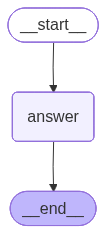

In [40]:
app

In [41]:
result = app.invoke({
    "question": "What is AI?"
})

print(result)

{'question': 'What is AI?', 'answer': 'Answering: What is AI?'}


## Tracing Memory

In [42]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
app = graph.compile(checkpointer=memory)

config = {
    "configurable": {"thread_id": "user-1"}
}

app.invoke({"question": "What is AI?"},config=config)

{'question': 'What is AI?', 'answer': 'Answering: What is AI?'}

In [43]:
# inspecting checkpoint state

state = app.get_state(
    {
        "configurable": {"thread_id": "user-1"}
    }
)
print(state)

StateSnapshot(values={'question': 'What is AI?', 'answer': 'Answering: What is AI?'}, next=(), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15c30d-459e-6c4c-8001-50373b0afd60'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-30T14:07:01.604456+00:00', parent_config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f15c30d-459c-62e4-8000-fdf687e31cab'}}, tasks=(), interrupts=())


## Message based Agent Memory

In [46]:
from typing import Annotated,TypedDict
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages:Annotated[list,add_messages]

In [47]:
def chatbot(state):
    response = llm.invoke(state['messages'])
    return {
        'messages':[response]
    }

## Custom state logging 

In [48]:
from langsmith import traceable
vector_store = [] 
@traceable
def retrieve_docs(query):
    docs = vectorstore.similarity_search(query)
    return docs